# Notebook 3 — Dependent Variables

Constructing and analysing the three binary dependent variables used in the modelling chapter.

| Variable | Label | Definition |
|---|---|---|
| Y1 | Has Credit | `Total Debt > 0` — firm carries any bank debt on balance |
| Y2 | Active Credit User | Has credit and is not actively repaying (debt change > −20%) |
| Y3 | Increasing Credit | Debt at year t strictly exceeds debt at year t−1 |

Y1 is available for all years (2018–2024). Y2 and Y3 require a lagged value and are available from 2019 onwards.

**Steps performed:**
1. Constructing Y1: Has Credit
2. Creating lag and change variables
3. Constructing Y3: Increasing Credit
4. Investigating debt decrease distribution (Y2 threshold justification)
5. Constructing Y2: Active Credit User
6. Dependent variable summary table and debt structure
7. Credit dynamics classification and portfolio charts
8. Credit access by sector and region

**Input:** `df_cleaned.csv` from Notebook 1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

## 0. Loading data, chart style and constants

Reading the cleaned dataset and defining all lookup tables and colour palette used throughout the notebook.

In [2]:
df = pd.read_csv('df_cleaned.csv', sep=';', encoding='utf-8', low_memory=False)
print('Dataset shape:', df.shape)

Dataset shape: (81062, 167)


In [3]:
plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    'figure.facecolor':  'white', 'figure.dpi': 150,
    'font.family':       'serif',
    'font.serif':        ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'font.size':         11,
    'axes.facecolor':    'white', 'axes.edgecolor':  '#2c2c2c',
    'axes.linewidth':    0.8,     'axes.titlesize':  13,
    'axes.titleweight':  'bold',  'axes.titlepad':   14,
    'axes.labelsize':    11,      'axes.labelcolor': '#2c2c2c',
    'axes.spines.top':   False,   'axes.spines.right': False,
    'grid.color':        '#e0e0e0', 'grid.linewidth': 0.6, 'grid.linestyle': '--',
    'xtick.labelsize':   10,      'ytick.labelsize': 10,
    'xtick.color':       '#2c2c2c', 'ytick.color':   '#2c2c2c',
    'legend.fontsize':   10,      'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'lines.linewidth':   2,       'lines.markersize': 7,
    'savefig.dpi':       300,     'savefig.bbox':    'tight',
    'savefig.facecolor': 'white',
})

COLORS = {
    'primary':   '#2c5f8a', 'secondary': '#4a9aba',
    'positive':  '#3ab5a5', 'negative':  '#d9534f',
    'neutral':   '#95a5a6', 'accent':    '#f0c060',
    'light':     '#ddeef7',
}

In [4]:
SECTOR_MAP = {
    'A': 'Agriculture',              'B': 'Mining',
    'C': 'Manufacturing',            'D': 'Energy',
    'E': 'Water & Waste',            'F': 'Construction',
    'G': 'Wholesale & Retail Trade', 'H': 'Transportation',
    'I': 'Accommodation & Food',     'J': 'Information & Communication',
    'K': 'Financial Services',       'L': 'Real Estate',
    'M': 'Professional Services',    'N': 'Administrative Services',
    'O': 'Public Administration',    'P': 'Education',
    'Q': 'Health & Social Work',     'R': 'Arts & Entertainment',
    'S': 'Other Services',
}

# Top sectors by revenue — used for sector group analysis
TOP_SECTORS = ['Wholesale & Retail Trade', 'Manufacturing',
               'Agriculture', 'Energy', 'Mining']

FRONTLINE_2014 = ['Донецька область', 'Луганська область']
FRONTLINE_2022 = ['Харківська область', 'Запорізька область',
                  'Херсонська область', 'Миколаївська область',
                  'Чернігівська область', 'Сумська область']

REGION_UA_TO_EN = {
    'Донецька область':          'Donetsk Oblast',
    'Луганська область':         'Luhansk Oblast',
    'Харківська область':        'Kharkiv Oblast',
    'Запорізька область':        'Zaporizhzhia Oblast',
    'Херсонська область':        'Kherson Oblast',
    'Миколаївська область':      'Mykolaiv Oblast',
    'Чернігівська область':      'Chernihiv Oblast',
    'Сумська область':           'Sumy Oblast',
}

# Display names for all regions (used in charts)
REGION_DISPLAY_MAP = {
    'м. Київ':                   'KievCity',
    'Дніпропетровська область':  'Dnipropetrovsk',
    'Київська область':          'Kyiv Region',
    'Львівська область':         'Lviv',
    'Харківська область':        'Kharkiv',
    'Одеська область':           'Odessa',
    'Полтавська область':        'Poltava',
    'Черкаська область':         'Cherkasy',
    'Вінницька область':         'Vinnytsia',
    'Волинська область':         'Volyn',
    'Запорізька область':        'Zaporizhzhia',
    'Кіровоградська область':    'Kirovohrad',
    'Миколаївська область':      'Mykolaiv',
    'Донецька область':          'Donetsk',
    'Закарпатська область':      'Zakarpattia',
    'Рівненська область':        'Rivne',
    'Чернігівська область':      'Chernihiv',
    'Тернопільська область':     'Ternopil',
    'Сумська область':           'Sumy',
    'Житомирська область':       'Zhytomyr',
    'Хмельницька область':       'Khmelnytskyi',
    'Івано-Франківська область': 'Ivano-Frankivsk',
    'Чернівецька область':       'Chernivtsi',
    'Херсонська область':        'Kherson',
    'Луганська область':         'Luhansk',
}

YEARS_FULL    = sorted(df['Year'].dropna().astype(int).unique())
YEARS_LAGGED  = [y for y in YEARS_FULL if y >= 2019]

In [5]:
# Assign sector group (top 5 by revenue + Other)
df['Sector Label'] = df['Sector'].map(SECTOR_MAP)
df['Sector Group'] = df['Sector Label'].apply(
    lambda x: x if x in TOP_SECTORS else 'Other'
)

# Assign region group
all_frontline = FRONTLINE_2014 + FRONTLINE_2022
other_regions = [r for r in df['Region'].unique()
                 if r not in all_frontline and r != 'м. Київ']

REGION_GROUPS = {
    'Kyiv City':           ['м. Київ'],
    'Conflict since 2014': FRONTLINE_2014,
    'Frontline from 2022': FRONTLINE_2022,
    'Other Regions':       other_regions,
}

def assign_region_group(region):
    for group, regions in REGION_GROUPS.items():
        if region in regions:
            return group
    return 'Other Regions'

df['Region Group'] = df['Region'].apply(assign_region_group)
df['Region EN']    = df['Region'].map(REGION_DISPLAY_MAP)

print('Sector groups:', df['Sector Group'].value_counts().to_dict())
print('Region groups:', df['Region Group'].value_counts().to_dict())

Sector groups: {'Other': 37993, 'Manufacturing': 13617, 'Agriculture': 13125, 'Wholesale & Retail Trade': 12283, 'Mining': 2248, 'Energy': 1796}
Region groups: {'Other Regions': 42041, 'Kyiv City': 23984, 'Frontline from 2022': 13203, 'Conflict since 2014': 1834}


In [6]:
df['Y1_Has_Credit'] = (df['Total Debt'].fillna(0) > 0).astype(float)

df_19 = df[df['Year'] >= 2019].copy()

total = len(df_19)
ones  = (df_19['Y1_Has_Credit'] == 1).sum()
zeros = (df_19['Y1_Has_Credit'] == 0).sum()

print('Y1 — Has Credit (2019–2024)')
print(f'  1 (has credit) : {ones:,} ({ones/total*100:.1f}%)')
print(f'  0 (no credit)  : {zeros:,} ({zeros/total*100:.1f}%)')

Y1 — Has Credit (2019–2024)
  1 (has credit) : 15,646 (22.3%)
  0 (no credit)  : 54,528 (77.7%)


## 2. Creating lag and change variables

Merging each observation at year t with Total Debt from year t−1 of the same firm. The resulting lag column enables construction of Y2 and Y3.

In [7]:
df = df.sort_values(['Firm ID', 'Year']).reset_index(drop=True)

# Shift debt one year forward to create t-1 lag
df_lag = df[['Firm ID', 'Year', 'Total Debt']].copy()
df_lag['Year'] = df_lag['Year'] + 1
df_lag = df_lag.rename(columns={'Total Debt': 'Total_Debt_lag1'})

df = df.merge(df_lag, on=['Firm ID', 'Year'], how='left')

df['Debt_Change']     = df['Total Debt'] - df['Total_Debt_lag1']
df['Debt_Change_pct'] = df['Debt_Change'] / df['Total_Debt_lag1'].replace(0, float('nan'))

print(f'Total_Debt_lag1 non-null : {df["Total_Debt_lag1"].notna().sum():,}')
print(f'Debt_Change non-null     : {df["Debt_Change"].notna().sum():,}')

Total_Debt_lag1 non-null : 60,513
Debt_Change non-null     : 60,513


## 3. Constructing Y3: "Increasing Credit"

Defining Y3 = 1 if Total Debt at year t strictly exceeds Total Debt at t−1. Observations without a lag receive NaN.

In [8]:
df['Y3_Increasing_Credit'] = (df['Debt_Change'] > 0).astype(float)
df.loc[df['Total_Debt_lag1'].isna(), 'Y3_Increasing_Credit'] = float('nan')

total = df['Y3_Increasing_Credit'].notna().sum()
ones  = (df['Y3_Increasing_Credit'] == 1).sum()
zeros = (df['Y3_Increasing_Credit'] == 0).sum()
nans  = df['Y3_Increasing_Credit'].isna().sum()

print('Y3 — Increasing Credit')
print(f'  1 (increasing) : {ones:,} ({ones/total*100:.1f}%)')
print(f'  0 (all others) : {zeros:,} ({zeros/total*100:.1f}%)')
print(f'  NaN (no lag)   : {nans:,}')

Y3 — Increasing Credit
  1 (increasing) : 7,539 (12.5%)
  0 (all others) : 52,974 (87.5%)
  NaN (no lag)   : 20,549


## 4. Debt decrease distribution — Y2 threshold justification

Examining the distribution of year-over-year debt decreases to justify the −20% repayment threshold used in Y2.

In [9]:
debt_decrease = df[
    (df['Total_Debt_lag1'] > 0) &
    (df['Debt_Change'] < 0) &
    df['Debt_Change_pct'].notna()
]['Debt_Change_pct']

print('Debt Decrease Distribution')
print(f'  Observations with decrease : {len(debt_decrease):,}')
print(f'  Mean                       : {debt_decrease.mean()*100:.1f}%')
print(f'  Median                     : {debt_decrease.median()*100:.1f}%')
print(f'  p10 / p25 / p75 / p90      : '
      f'{debt_decrease.quantile(0.10)*100:.1f}% / '
      f'{debt_decrease.quantile(0.25)*100:.1f}% / '
      f'{debt_decrease.quantile(0.75)*100:.1f}% / '
      f'{debt_decrease.quantile(0.90)*100:.1f}%')

print('\nShare by repayment threshold:')
for t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.50, 1.00]:
    n   = (debt_decrease < -t).sum()
    pct = n / len(debt_decrease) * 100
    print(f'  Decrease > {t*100:.0f}% : {n:,} ({pct:.1f}% of decreasing obs)')

Debt Decrease Distribution
  Observations with decrease : 7,341
  Mean                       : -54.2%
  Median                     : -48.6%
  p10 / p25 / p75 / p90      : -100.0% / -100.0% / -18.6% / -6.5%

Share by repayment threshold:
  Decrease > 10% : 6,271 (85.4% of decreasing obs)
  Decrease > 15% : 5,784 (78.8% of decreasing obs)
  Decrease > 20% : 5,385 (73.4% of decreasing obs)
  Decrease > 25% : 4,972 (67.7% of decreasing obs)
  Decrease > 30% : 4,623 (63.0% of decreasing obs)
  Decrease > 50% : 3,586 (48.8% of decreasing obs)
  Decrease > 100% : 0 (0.0% of decreasing obs)


## 5. Constructing Y2: "Active Credit User"

Defining Y2 = 1 if the firm carries bank debt and is not actively repaying it (debt change ≥ −20%). The −20% threshold is consistent with NBU expert guidance and confirmed by p75 of decreases in the data.

In [10]:
df['Y2_Active_Credit_User'] = 1.0

# 0 if no credit on balance
df.loc[df['Total Debt'].fillna(0) == 0, 'Y2_Active_Credit_User'] = 0.0

# 0 if actively repaying (debt decreased by more than 20%)
df.loc[df['Debt_Change_pct'] < -0.20, 'Y2_Active_Credit_User'] = 0.0

# NaN where no lag is available
df.loc[df['Total_Debt_lag1'].isna(), 'Y2_Active_Credit_User'] = float('nan')

total = df['Y2_Active_Credit_User'].notna().sum()
ones  = (df['Y2_Active_Credit_User'] == 1).sum()
zeros = (df['Y2_Active_Credit_User'] == 0).sum()
nans  = df['Y2_Active_Credit_User'].isna().sum()

print('Y2 — Active Credit User (threshold: −20%)')
print(f'  1 (active user)    : {ones:,} ({ones/total*100:.1f}%)')
print(f'  0 (no / repaying)  : {zeros:,} ({zeros/total*100:.1f}%)')
print(f'  NaN (no lag)       : {nans:,}')

Y2 — Active Credit User (threshold: −20%)
  1 (active user)    : 10,344 (17.1%)
  0 (no / repaying)  : 50,169 (82.9%)
  NaN (no lag)       : 20,549


## 6. Dependent variables summary table

Summarising all three dependent variables in a single comparison table.

In [11]:
df_19 = df[df['Year'] >= 2019].copy()
summary_rows = []
for var, label, note in [
    ('Y1_Has_Credit',         'Y1: Has Credit',         'Total Debt > 0'),
    ('Y2_Active_Credit_User', 'Y2: Active Credit User',  'Has credit and debt change ≥ −20%'),
    ('Y3_Increasing_Credit',  'Y3: Increasing Credit',   'Total Debt > Total Debt (t−1)'),
]:
    total = df_19[var].notna().sum()
    ones  = (df_19[var] == 1).sum()
    zeros = (df_19[var] == 0).sum()
    nans  = df_19[var].isna().sum()
    summary_rows.append({
        'Variable'      : label,
        'Definition'    : note,
        '= 1 (n)'       : ones,
        '= 1 (%)'       : f'{ones/total*100:.1f}%',
        '= 0 (n)'       : zeros,
        '= 0 (%)'       : f'{zeros/total*100:.1f}%',
        'N (excl. NaN)' : total,
        'NaN'           : nans,
    })

print('Dependent Variables — Summary (2019–2024)')
print('=' * 90)
print(pd.DataFrame(summary_rows).to_string(index=False))

Dependent Variables — Summary (2019–2024)
              Variable                        Definition  = 1 (n) = 1 (%)  = 0 (n) = 0 (%)  N (excl. NaN)  NaN
        Y1: Has Credit                    Total Debt > 0    15646   22.3%    54528   77.7%          70174    0
Y2: Active Credit User Has credit and debt change ≥ −20%    10344   17.1%    50169   82.9%          60513 9661
 Y3: Increasing Credit     Total Debt > Total Debt (t−1)     7539   12.5%    52974   87.5%          60513 9661


## 7. Debt structure: Short-Term vs Long-Term

Breaking down total bank debt into short-term and long-term components for 2019–2024.

In [12]:


debt_agg = df_19.agg({
    'Short-Term Bank Loans': 'sum',
    'Long-Term Bank Loans':  'sum',
    'Total Debt':            'sum',
})
st, lt, tot = [debt_agg[c] / 1_000_000 for c in
               ['Short-Term Bank Loans', 'Long-Term Bank Loans', 'Total Debt']]

print('DEBT STRUCTURE (2019–2024)')
print(f'Short-Term Bank Loans : {st:.1f} bn UAH ({st/tot*100:.1f}%)')
print(f'Long-Term Bank Loans  : {lt:.1f} bn UAH ({lt/tot*100:.1f}%)')
print(f'Total Debt            : {tot:.1f} bn UAH (100%)')

debt_by_year = (
    df_19.groupby('Year')
    .agg(ST=('Short-Term Bank Loans', 'sum'),
         LT=('Long-Term Bank Loans',  'sum'),
         Total=('Total Debt',         'sum'))
    .reset_index()
)
debt_by_year['Year']       = debt_by_year['Year'].astype(int)
debt_by_year['ST (bn)']    = (debt_by_year['ST']    / 1e6).round(1)
debt_by_year['LT (bn)']    = (debt_by_year['LT']    / 1e6).round(1)
debt_by_year['Total (bn)'] = (debt_by_year['Total'] / 1e6).round(1)
debt_by_year['ST (%)']     = (debt_by_year['ST'] / debt_by_year['Total'] * 100).round(1)
debt_by_year['LT (%)']     = (debt_by_year['LT'] / debt_by_year['Total'] * 100).round(1)

print('\nBy Year:')
print(debt_by_year[['Year','ST (bn)','LT (bn)','Total (bn)','ST (%)','LT (%)']]
      .to_string(index=False))

DEBT STRUCTURE (2019–2024)
Short-Term Bank Loans : 1018.7 bn UAH (55.9%)
Long-Term Bank Loans  : 804.0 bn UAH (44.1%)
Total Debt            : 1822.7 bn UAH (100%)

By Year:
 Year  ST (bn)  LT (bn)  Total (bn)  ST (%)  LT (%)
 2019    143.8    129.0       272.7    52.7    47.3
 2020    128.2    127.7       255.9    50.1    49.9
 2021    173.3    114.0       287.3    60.3    39.7
 2022    204.9    115.9       320.8    63.9    36.1
 2023    165.1    161.9       327.1    50.5    49.5
 2024    203.4    155.5       358.9    56.7    43.3


## 8. Y1 by Year — detailed view

Computing the share of firms with credit and total debt portfolio per year, including year-over-year change.

In [13]:
proxy1_by_year = (
    df_19.groupby('Year')
    .agg(
        Total_Firms  = ('Firm ID',          'nunique'),
        Has_Credit_N = ('Y1_Has_Credit',     'sum'),
        Total_Debt   = ('Total Debt',        'sum'),
    ).reset_index()
)
proxy1_by_year['Year']            = proxy1_by_year['Year'].astype(int)
proxy1_by_year['Has_Credit_%']    = (proxy1_by_year['Has_Credit_N'] /
                                     proxy1_by_year['Total_Firms'] * 100).round(1)
proxy1_by_year['Total_Debt (bn)'] = (proxy1_by_year['Total_Debt'] / 1_000_000).round(1)

# Debt among firms with credit — include 2018 for YoY base
debt_credit = (
    df[df['Y1_Has_Credit'] == 1]
    .groupby('Year')['Total Debt'].sum()
    .reset_index()
    .rename(columns={'Total Debt': 'Debt_w_credit'})
)
debt_credit['Year']             = debt_credit['Year'].astype(int)
debt_credit['Debt_credit (bn)'] = (debt_credit['Debt_w_credit'] / 1_000_000).round(1)
debt_credit['YoY (%)']          = (debt_credit['Debt_credit (bn)'].pct_change() * 100).round(1)

proxy1_by_year = proxy1_by_year.merge(
    debt_credit[['Year', 'Debt_credit (bn)', 'YoY (%)']], on='Year'
)
proxy1_by_year['Debt_credit_%'] = (
    proxy1_by_year['Debt_credit (bn)'] / proxy1_by_year['Total_Debt (bn)'] * 100
).round(1)

print('Y1: HAS CREDIT — BY YEAR')
print('=' * 80)
print(proxy1_by_year[['Year','Total_Firms','Has_Credit_N','Has_Credit_%',
                       'Total_Debt (bn)','Debt_credit (bn)','Debt_credit_%',
                       'YoY (%)']].to_string(index=False))

Y1: HAS CREDIT — BY YEAR
 Year  Total_Firms  Has_Credit_N  Has_Credit_%  Total_Debt (bn)  Debt_credit (bn)  Debt_credit_%  YoY (%)
 2019        12493        3088.0          24.7            272.7             272.7          100.0     -2.7
 2020        10651        2003.0          18.8            255.9             255.9          100.0     -6.2
 2021        12603        2892.0          22.9            287.3             287.3          100.0     12.3
 2022        12086        2743.0          22.7            320.8             320.8          100.0     11.7
 2023        11867        2604.0          21.9            327.1             327.1          100.0      2.0
 2024        10474        2316.0          22.1            358.9             358.9          100.0      9.7


## 9. Credit dynamics classification

Classifying each firm-year observation (where a lag exists) into one of five mutually exclusive categories: New Credit, Increasing, Stable, Actively Repaying, Fully Repaid.

In [14]:
def classify_credit_dynamic(row):
    prev    = row['Total_Debt_lag1']
    current = row['Total Debt']
    pct     = row['Debt_Change_pct']

    if prev == 0 and current > 0:
        return 'New Credit'
    elif prev > 0 and current > prev:
        return 'Increasing'
    elif prev > 0 and current > 0 and pct >= -0.20:
        return 'Stable'
    elif prev > 0 and current > 0 and pct < -0.20:
        return 'Actively Repaying'
    elif prev > 0 and current == 0:
        return 'Fully Repaid'
    else:
        return None  # no credit in either period

df_lag_all = df[df['Total_Debt_lag1'].notna()].copy()
df_lag_all['Credit_Dynamic'] = df_lag_all.apply(classify_credit_dynamic, axis=1)
df_credit = df_lag_all[df_lag_all['Credit_Dynamic'].notna()].copy()

result = (
    df_credit.groupby(['Year', 'Credit_Dynamic'])
    .size().unstack(fill_value=0)
)
result['Total'] = result.sum(axis=1)
result.index    = result.index.astype(int)

pct_result = result.drop(columns='Total').div(result['Total'], axis=0) * 100

print('Credit dynamics — firms with credit history:')
print(result.to_string())
print('\nAs % of total per year:')
print(pct_result.round(1).to_string())

Credit dynamics — firms with credit history:
Credit_Dynamic  Actively Repaying  Fully Repaid  Increasing  New Credit  Stable  Total
Year                                                                                  
2019                          667           438        1049         447     597   3198
2020                          411           377         713         289     363   2153
2021                          326           290         731         416     303   2066
2022                          537           405        1121         327     543   2933
2023                          649           362         930         253     522   2716
2024                          576           347         956         307     477   2663

As % of total per year:
Credit_Dynamic  Actively Repaying  Fully Repaid  Increasing  New Credit  Stable
Year                                                                           
2019                         20.9          13.7        32.8        14.0   

## 10. Credit portfolio by dynamic category

Computing total debt (bn UAH) per dynamic category per year. Using the corrected merge approach: matching dynamics back to all Y1=1 observations to avoid undercounting.

In [15]:
# Merge dynamic category onto all firms with credit in 2019-2024
df_with_dynamic = (
    df[(df['Y1_Has_Credit'] == 1) & (df['Year'] != 2018.0)]
    .merge(
        df_credit[['Firm ID', 'Year', 'Credit_Dynamic']],
        on=['Firm ID', 'Year'], how='left'
    )
)

print(f"Matched   : {df_with_dynamic['Credit_Dynamic'].notna().sum():,}")
print(f"Unmatched : {df_with_dynamic['Credit_Dynamic'].isna().sum():,}")

portfolio_long = (
    df_with_dynamic.groupby(['Year', 'Credit_Dynamic'])['Total Debt']
    .sum().reset_index()
)
portfolio_long['Year']           = portfolio_long['Year'].astype(int)
portfolio_long['Total (bn UAH)'] = (portfolio_long['Total Debt'] / 1_000_000).round(1)
portfolio_long = portfolio_long[portfolio_long['Credit_Dynamic'] != 'Fully Repaid']

portfolio_pivot = (
    portfolio_long.pivot(index='Year', columns='Credit_Dynamic', values='Total (bn UAH)')
    .fillna(0)
)
portfolio_pivot['TOTAL'] = portfolio_pivot.sum(axis=1)

print('\nCredit Portfolio by Dynamic Category (bn UAH):')
print(portfolio_pivot.to_string())

Matched   : 13,510
Unmatched : 2,136

Credit Portfolio by Dynamic Category (bn UAH):
Credit_Dynamic  Actively Repaying  Increasing  New Credit  Stable  TOTAL
Year                                                                    
2019                         62.3        69.7        20.4    84.6  237.0
2020                         24.9       132.2        13.0    50.7  220.8
2021                         25.4        91.4        15.3    68.8  200.9
2022                         15.5       228.6        11.0    41.9  297.0
2023                         28.0       161.2        15.0    61.2  265.4
2024                         26.9       261.8        10.5    59.6  358.8


## 11. Credit portfolio chart — stacked bars + two lines

Plotting total debt stacked by dynamic category, with a total portfolio line (Y1) and an active portfolio line (Increasing + New Credit + Stable).

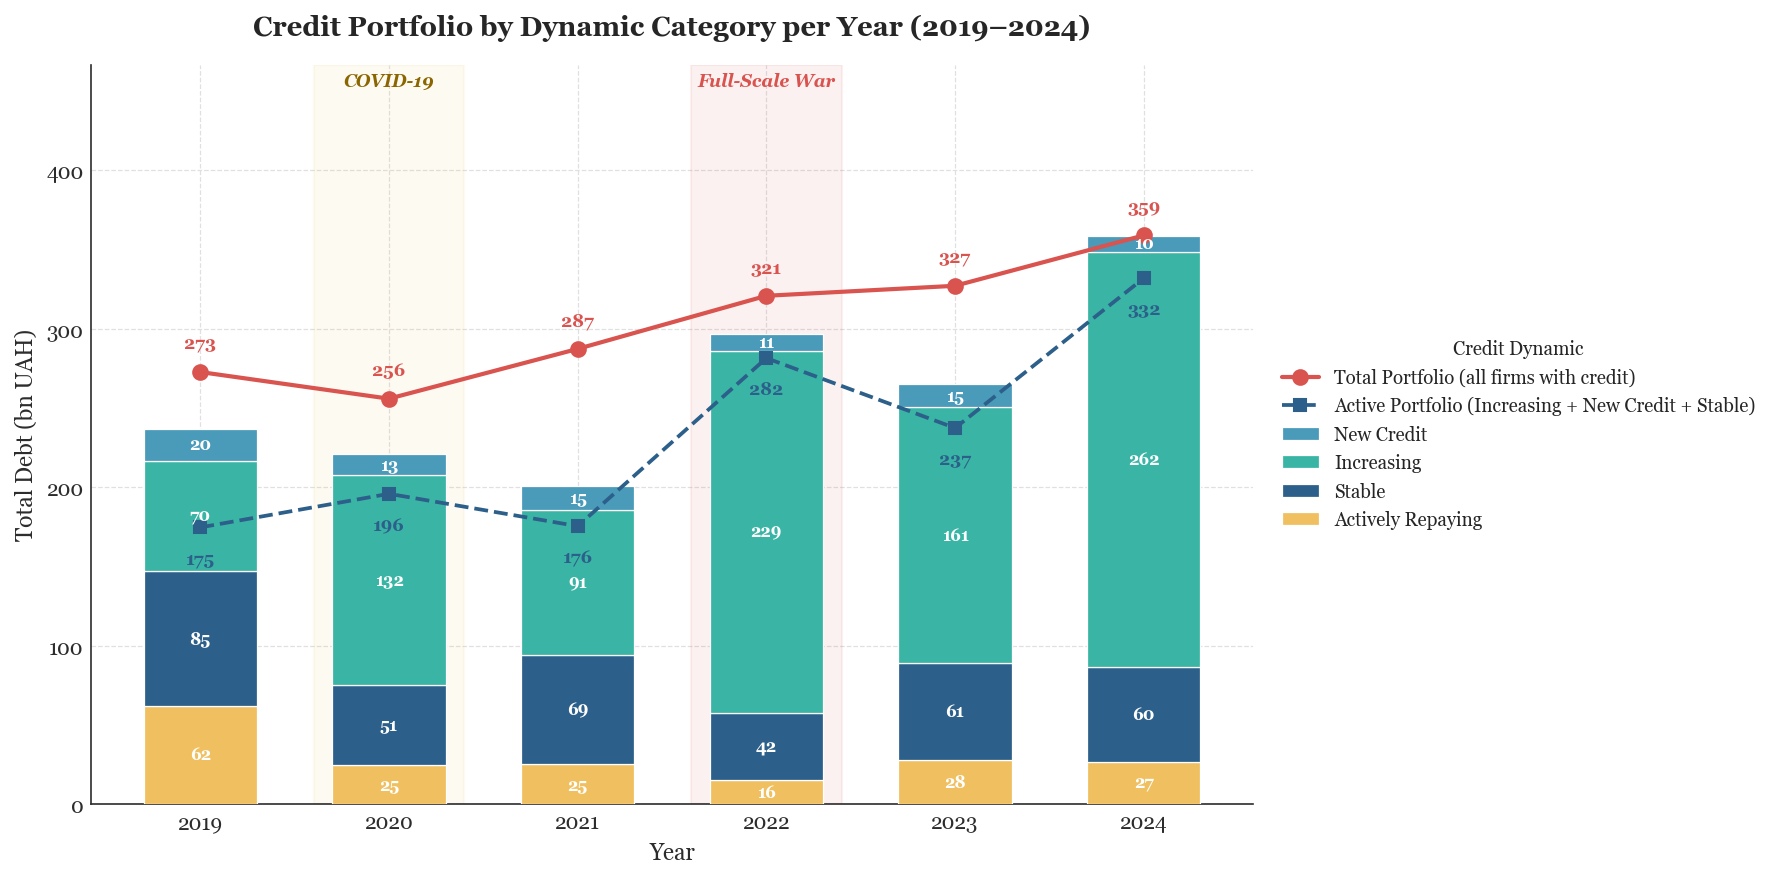

In [16]:
CATEGORY_COLORS = {
    'Increasing':        COLORS['positive'],
    'New Credit':        COLORS['secondary'],
    'Stable':            COLORS['primary'],
    'Actively Repaying': COLORS['accent'],
}

# Total portfolio line (Y1)
total_y1 = (
    df[(df['Y1_Has_Credit'] == 1) & (df['Year'] != 2018.0)]
    .groupby('Year')['Total Debt'].sum().reset_index()
)
total_y1['Year']       = total_y1['Year'].astype(int)
total_y1['Total (bn)'] = (total_y1['Total Debt'] / 1_000_000).round(1)

# Active portfolio line
active_cats  = ['Increasing', 'New Credit', 'Stable']
total_active = (
    portfolio_long[portfolio_long['Credit_Dynamic'].isin(active_cats)]
    .groupby('Year')['Total (bn UAH)'].sum()
    .reset_index().rename(columns={'Total (bn UAH)': 'Active (bn)'})
)

years = portfolio_pivot.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))

bottom = [0.0] * len(years)
for category in ['Actively Repaying', 'Stable', 'Increasing', 'New Credit']:
    if category not in portfolio_pivot.columns:
        continue
    values = portfolio_pivot[category].tolist()
    bars   = ax.bar(years, values, bottom=bottom,
                    label=category, color=CATEGORY_COLORS[category],
                    edgecolor='white', linewidth=0.6, width=0.6, zorder=3)
    for bar, val, bot in zip(bars, values, bottom):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bot + val / 2,
                    f'{val:.0f}', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold', zorder=7)
    bottom = [b + v for b, v in zip(bottom, values)]

ax.plot(total_y1['Year'], total_y1['Total (bn)'],
        marker='o', markersize=7, color=COLORS['negative'],
        linewidth=2.0, zorder=6,
        label='Total Portfolio (all firms with credit)')
for _, row in total_y1.iterrows():
    ax.text(row['Year'], row['Total (bn)'] + total_y1['Total (bn)'].max() * 0.04,
            f"{row['Total (bn)']:.0f}",
            ha='center', fontsize=8.5, color=COLORS['negative'], fontweight='bold')

ax.plot(total_active['Year'], total_active['Active (bn)'],
        marker='s', markersize=6, color=COLORS['primary'],
        linewidth=1.8, linestyle='--', zorder=6,
        label='Active Portfolio (Increasing + New Credit + Stable)')
for _, row in total_active.iterrows():
    ax.text(row['Year'], row['Active (bn)'] - total_active['Active (bn)'].max() * 0.07,
            f"{row['Active (bn)']:.0f}",
            ha='center', fontsize=8.5, color=COLORS['primary'], fontweight='bold')

y_max = total_y1['Total (bn)'].max() * 1.30
ax.axvspan(2019.6, 2020.4, alpha=0.08, color=COLORS['accent'],   zorder=2)
ax.axvspan(2021.6, 2022.4, alpha=0.08, color=COLORS['negative'], zorder=2)
ax.text(2020, y_max * 0.97, 'COVID-19',    ha='center', fontsize=8.5,
        color='#8a6500',        fontweight='bold', style='italic')
ax.text(2022, y_max * 0.97, 'Full-Scale War', ha='center', fontsize=8.5,
        color=COLORS['negative'], fontweight='bold', style='italic')

ax.set_title('Credit Portfolio by Dynamic Category per Year (2019–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Debt (bn UAH)')
ax.set_xticks(years)
ax.set_ylim(0, y_max)

handles, labels = ax.get_legend_handles_labels()
legend_order = ['Total Portfolio (all firms with credit)',
                'Active Portfolio (Increasing + New Credit + Stable)',
                'New Credit', 'Increasing', 'Stable', 'Actively Repaying']
ordered = [(h, l) for lo in legend_order for h, l in zip(handles, labels) if l == lo]
ax.legend(*zip(*ordered), loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=9, title='Credit Dynamic', title_fontsize=9)

plt.tight_layout()
plt.savefig('credit_portfolio_stacked_lines.png', bbox_inches='tight')
plt.show()

## 12. Credit dynamics area chart

Showing the share of each dynamic category among firms with credit history as a stacked area chart.

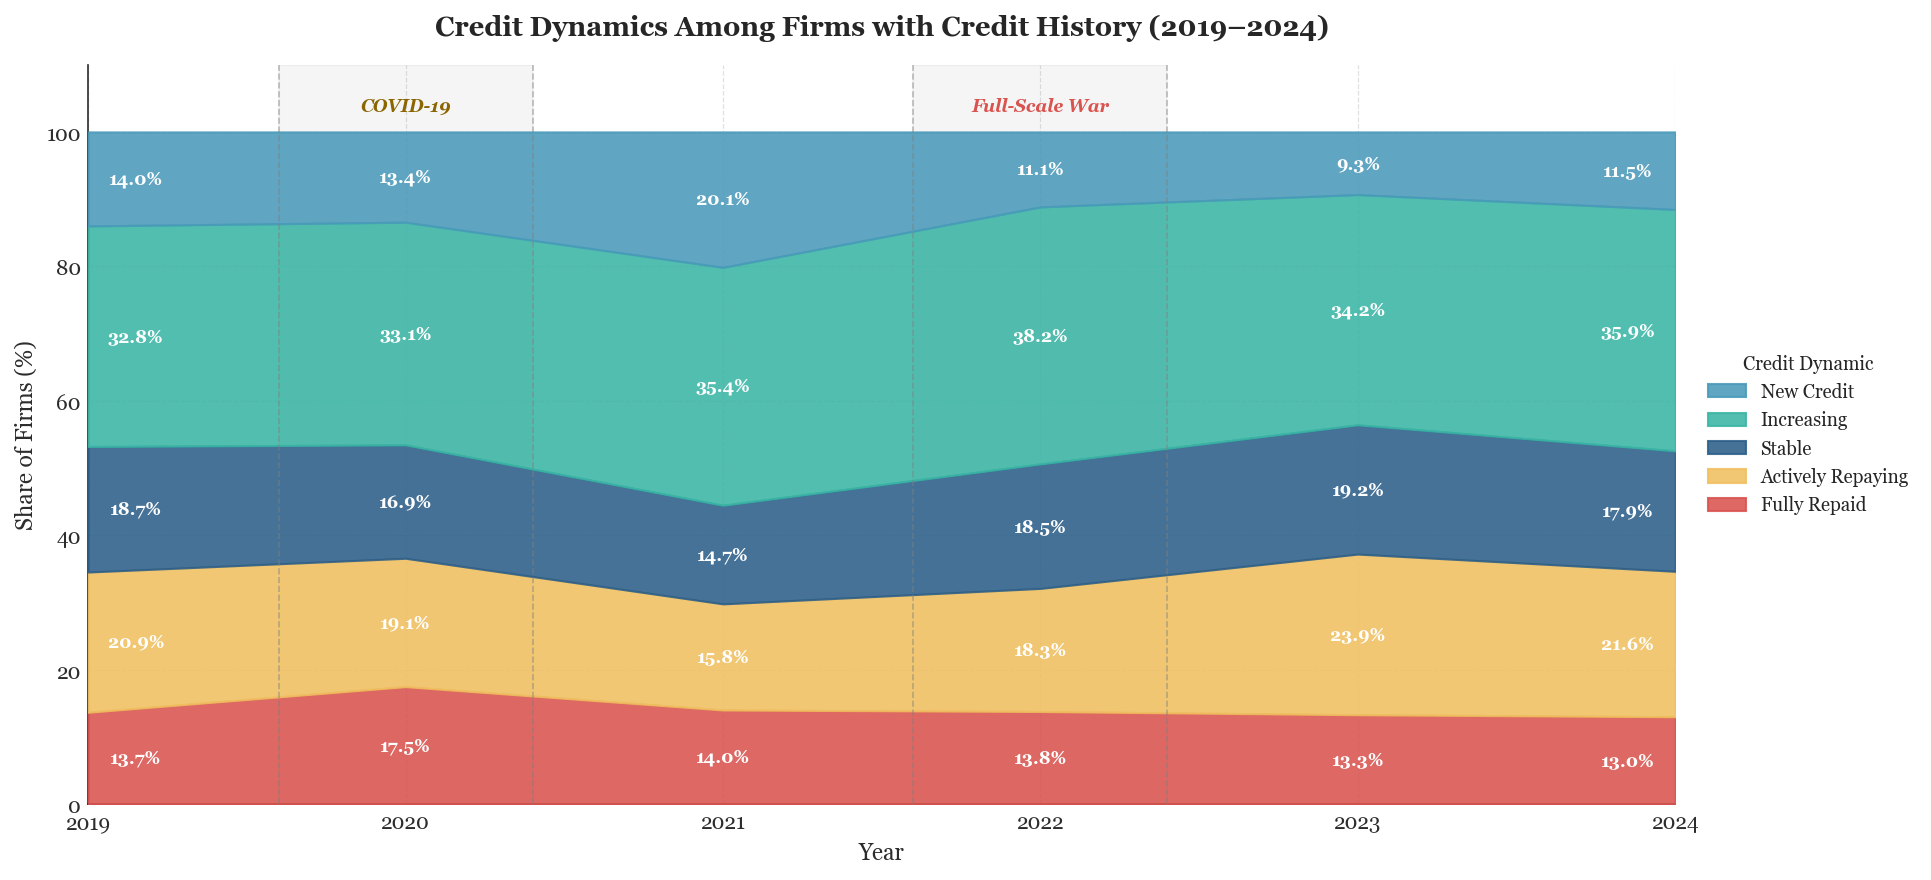

In [17]:
DYNAMIC_COLORS = {
    'Increasing':        COLORS['positive'],
    'New Credit':        COLORS['secondary'],
    'Stable':            COLORS['primary'],
    'Actively Repaying': COLORS['accent'],
    'Fully Repaid':      COLORS['negative'],
}

category_order = ['Fully Repaid', 'Actively Repaying', 'Stable', 'Increasing', 'New Credit']
years          = pct_result.index.tolist()

fig, ax = plt.subplots(figsize=(13, 6))
bottoms = [0.0] * len(years)

for category in category_order:
    if category not in pct_result.columns:
        continue
    values = pct_result[category].tolist()
    tops   = [b + v for b, v in zip(bottoms, values)]

    ax.fill_between(years, bottoms, tops,
                    alpha=0.88, color=DYNAMIC_COLORS[category],
                    label=category, zorder=3)

    for year, val, bot in zip(years, values, bottoms):
        if val >= 3:
            x_off = 0.15 if year == min(years) else (-0.15 if year == max(years) else 0)
            ax.text(year + x_off, bot + val / 2,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold', zorder=5)
    bottoms = tops

for x_start, x_end in [(2019.6, 2020.4), (2021.6, 2022.4)]:
    ax.axvspan(x_start, x_end, alpha=0.08, color='grey', zorder=2)
    for x in [x_start, x_end]:
        ax.axvline(x=x, color='grey', linewidth=0.8, linestyle='--', alpha=0.5, zorder=4)

ax.text(2020, 103, 'COVID-19',       ha='center', fontsize=8.5,
        color='#8a6500',        fontweight='bold', style='italic')
ax.text(2022, 103, 'Full-Scale War', ha='center', fontsize=8.5,
        color=COLORS['negative'], fontweight='bold', style='italic')

ax.set_title('Credit Dynamics Among Firms with Credit History (2019–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share of Firms (%)')
ax.set_xticks(years)
ax.set_xlim(min(years), max(years))
ax.set_ylim(0, 110)

handles, labels = ax.get_legend_handles_labels()
legend_order    = ['New Credit', 'Increasing', 'Stable', 'Actively Repaying', 'Fully Repaid']
ordered = [(h, l) for lo in legend_order for h, l in zip(handles, labels) if l == lo]
ax.legend(*zip(*ordered), loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=9, title='Credit Dynamic', title_fontsize=9)

plt.tight_layout()
plt.savefig('credit_dynamics_area.png')
plt.show()

## 13. All three dependent variables — overlapping areas

Visualising Y1, Y2, and Y3 as nested filled areas to illustrate how each variable is a progressively narrower subset of the previous.

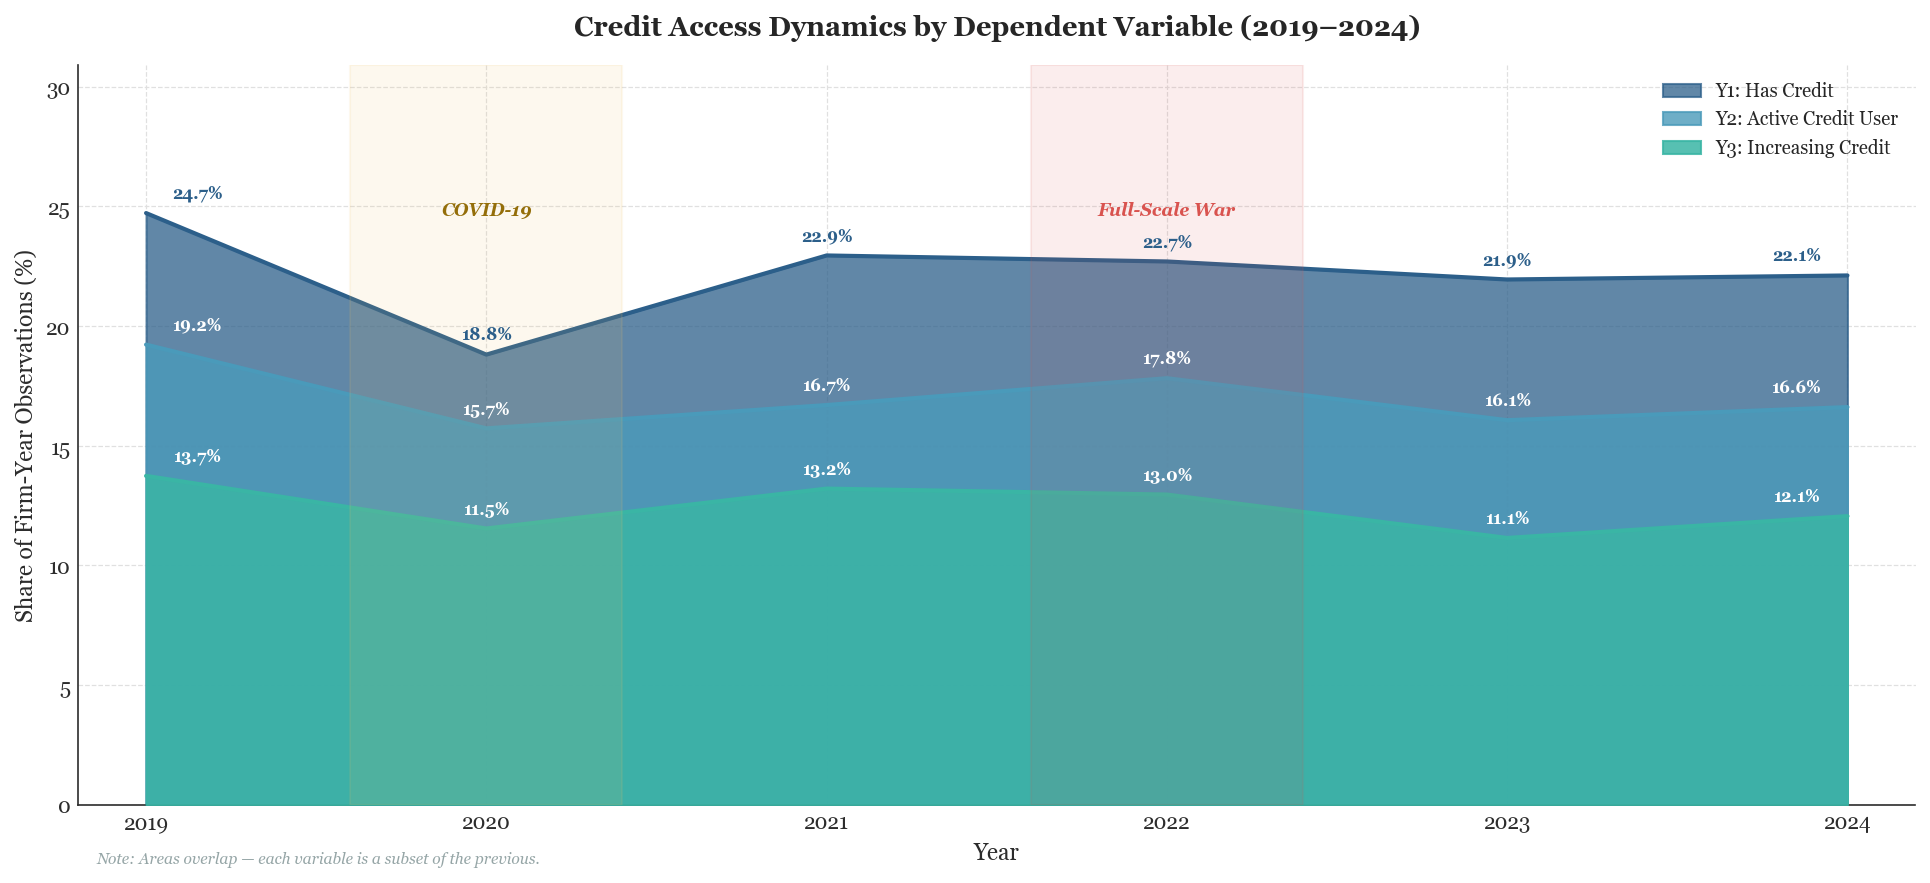

In [18]:
dep_var_year = (
    df.groupby('Year')
    .agg(
        Y1 = ('Y1_Has_Credit',        'mean'),
        Y2 = ('Y2_Active_Credit_User', 'mean'),
        Y3 = ('Y3_Increasing_Credit',  'mean'),
    ).reset_index()
)
dep_var_year['Year'] = dep_var_year['Year'].astype(int)
dep_var_year[['Y1','Y2','Y3']] = dep_var_year[['Y1','Y2','Y3']] * 100
dep_var_year = dep_var_year[dep_var_year['Year'] >= 2019].reset_index(drop=True)

years = dep_var_year['Year'].tolist()

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

for col, color, label in [
    ('Y1', COLORS['primary'],   'Y1: Has Credit'),
    ('Y2', COLORS['secondary'], 'Y2: Active Credit User'),
    ('Y3', COLORS['positive'],  'Y3: Increasing Credit'),
]:
    ax.fill_between(years, 0, dep_var_year[col],
                    color=color, alpha=0.75 + ['Y1','Y2','Y3'].index(col) * 0.05,
                    zorder=['Y1','Y2','Y3'].index(col) + 1, label=label)
    ax.plot(years, dep_var_year[col], color=color, linewidth=2.0,
            zorder=4)

for _, row in dep_var_year.iterrows():
    year  = row['Year']
    x_off = 0.15 if year == min(years) else (-0.15 if year == max(years) else 0)
    for col, color, va_off in [('Y1', COLORS['primary'], 0.6),
                                ('Y2', 'white', 0.6),
                                ('Y3', 'white', 0.6)]:
        ax.text(year + x_off, row[col] + va_off,
                f"{row[col]:.1f}%",
                ha='center', fontsize=8, color=color,
                fontweight='bold', zorder=7)

ax.axvspan(2019.6, 2020.4, alpha=0.10, color=COLORS['accent'],   zorder=6)
ax.axvspan(2021.6, 2022.4, alpha=0.10, color=COLORS['negative'], zorder=6)
ax.text(2020, ax.get_ylim()[1] * 0.97, 'COVID-19',
        ha='center', fontsize=8.5, color='#8a6500',
        fontweight='bold', style='italic', va='top')
ax.text(2022, ax.get_ylim()[1] * 0.97, 'Full-Scale War',
        ha='center', fontsize=8.5, color=COLORS['negative'],
        fontweight='bold', style='italic', va='top')

ax.set_title('Credit Access Dynamics by Dependent Variable (2019–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share of Firm-Year Observations (%)')
ax.set_xticks(years)
ax.set_xlim(min(years) - 0.2, max(years) + 0.2)
ax.set_ylim(0, dep_var_year['Y1'].max() * 1.25)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.text(0.01, -0.08, 'Note: Areas overlap — each variable is a subset of the previous.',
        transform=ax.transAxes, fontsize=7.5, color=COLORS['neutral'], style='italic')

plt.tight_layout()
plt.savefig('dep_var_overlapping_areas.png', dpi=150)
plt.show()

## 14. Credit access by sector

Computing share of firms with credit, total debt, and median debt per sector. Visualising as paired horizontal bar charts.

In [19]:
sector_credit = df_19.groupby('Sector').agg(
    Unique_Firms = ('Firm ID',       'nunique'),
    Has_Credit   = ('Y1_Has_Credit', 'mean'),
    Increasing   = ('Y3_Increasing_Credit', 'mean'),
    Total_Debt   = ('Total Debt',    'sum'),
).reset_index()

median_debt = (
    df_19[df_19['Total Debt'] > 0]
    .groupby('Sector')['Total Debt'].median()
    .reset_index().rename(columns={'Total Debt': 'Median_Debt'})
)
sector_credit = sector_credit.merge(median_debt, on='Sector', how='left')
sector_credit['Sector Label']          = sector_credit['Sector'].map(SECTOR_MAP)
sector_credit['Has Credit (%)']        = (sector_credit['Has_Credit']  * 100).round(1)
sector_credit['Increasing (%)']        = (sector_credit['Increasing']  * 100).round(1)
sector_credit['Median Debt (mln UAH)'] = (sector_credit['Median_Debt'] / 1000).round(1)
sector_credit['Total Debt (bn UAH)']   = (sector_credit['Total_Debt']  / 1_000_000).round(1)
sector_credit = sector_credit.sort_values('Has Credit (%)', ascending=False)

print('Credit Access by Sector (2019–2024):')
print(sector_credit[['Sector Label','Unique_Firms','Has Credit (%)','Increasing (%)',
                      'Median Debt (mln UAH)','Total Debt (bn UAH)']].to_string(index=False))

Credit Access by Sector (2019–2024):
               Sector Label  Unique_Firms  Has Credit (%)  Increasing (%)  Median Debt (mln UAH)  Total Debt (bn UAH)
                Agriculture          2854            46.5            26.4                   17.7                328.3
              Manufacturing          2957            35.6            19.8                   17.7                416.4
   Wholesale & Retail Trade          2901            31.5            18.5                   23.4                397.4
             Transportation           735            24.9            12.3                   18.6                 98.6
                     Energy           442            20.3            11.5                   92.5                234.8
               Construction           754            17.2             8.9                    6.9                 43.1
                     Mining           476            12.9             6.7                   10.0                 39.4
              Water

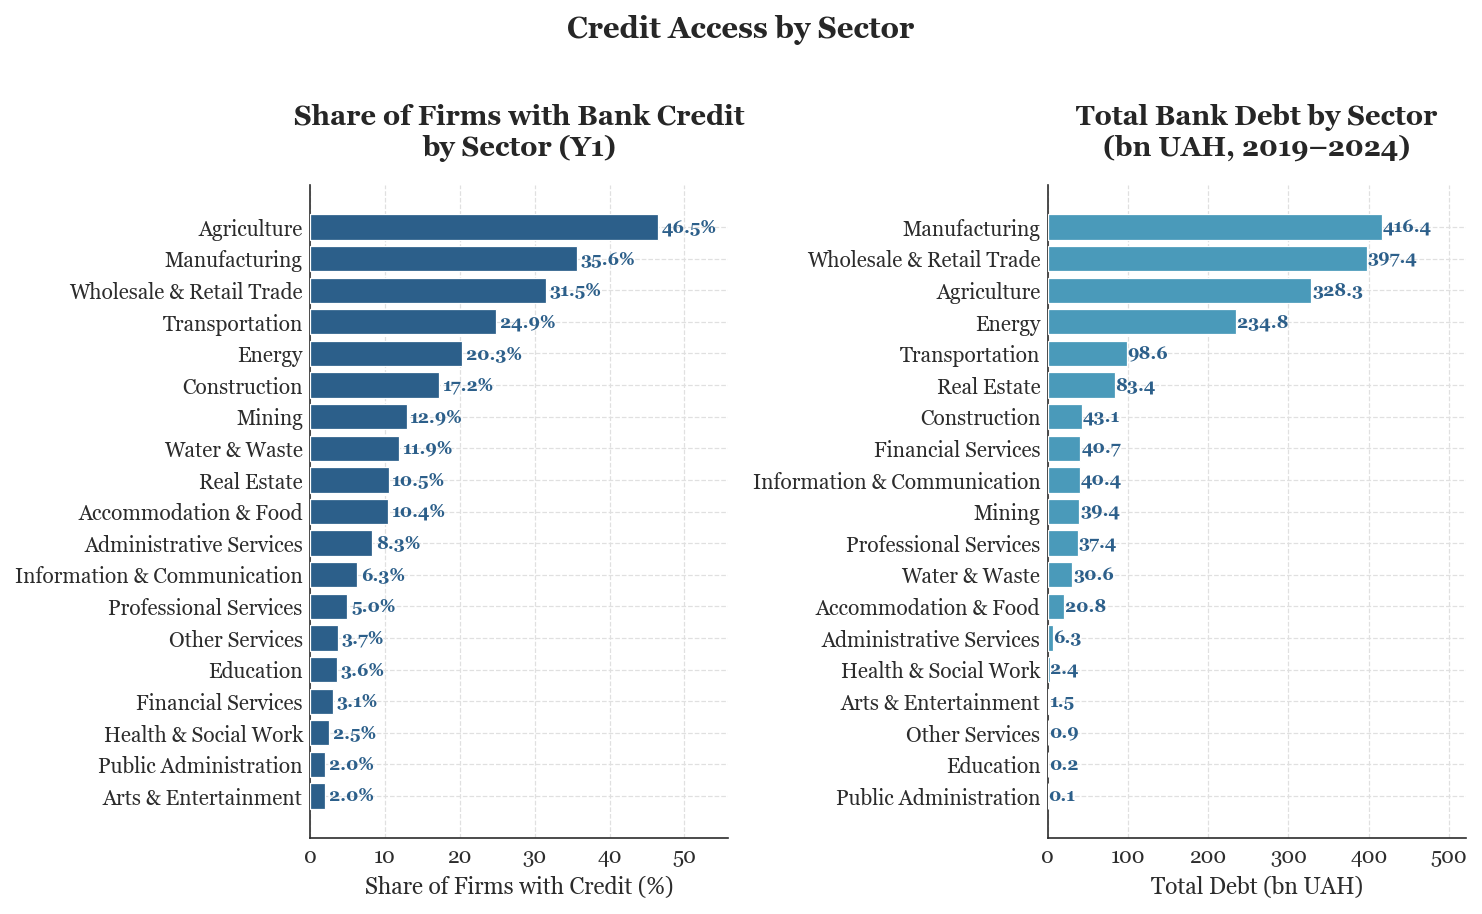

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Panel 1: share of firms with credit
bars = axes[0].barh(sector_credit['Sector Label'], sector_credit['Has Credit (%)'],
                    color=COLORS['primary'], edgecolor='white', linewidth=0.6, zorder=3)
for bar, val in zip(bars, sector_credit['Has Credit (%)']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=8.5,
                 color=COLORS['primary'], fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('Share of Firms with Credit (%)')
axes[0].set_title('Share of Firms with Bank Credit\nby Sector (Y1)')
axes[0].set_xlim(0, sector_credit['Has Credit (%)'].max() * 1.2)

# Panel 2: total debt by sector
sector_debt = sector_credit.sort_values('Total Debt (bn UAH)', ascending=False)
bars2 = axes[1].barh(sector_debt['Sector Label'], sector_debt['Total Debt (bn UAH)'],
                     color=COLORS['secondary'], edgecolor='white', linewidth=0.6, zorder=3)
for bar, val in zip(bars2, sector_debt['Total Debt (bn UAH)']):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}', va='center', fontsize=8.5,
                 color=COLORS['primary'], fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlabel('Total Debt (bn UAH)')
axes[1].set_title('Total Bank Debt by Sector\n(bn UAH, 2019–2024)')
axes[1].set_xlim(0, sector_debt['Total Debt (bn UAH)'].max() * 1.25)

plt.suptitle('Credit Access by Sector', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('credit_access_by_sector.png')
plt.show()

## 15. Credit access and debt by sector group — time series

Tracking Y1 share and total debt over 2019–2024 for the top-5 revenue sectors and the Other group.

In [21]:
SECTOR_GROUP_COLORS = {
    'Wholesale & Retail Trade': COLORS['primary'],
    'Manufacturing':            COLORS['positive'],
    'Agriculture':              COLORS['negative'],
    'Energy':                   COLORS['accent'],
    'Mining':                   COLORS['secondary'],
    'Other':                    COLORS['neutral'],
}

sector_credit_year = (
    df_19.groupby(['Year', 'Sector Group'])['Y1_Has_Credit']
    .mean().reset_index()
    .rename(columns={'Y1_Has_Credit': 'Has Credit (%)'})
)
sector_credit_year['Year']           = sector_credit_year['Year'].astype(int)
sector_credit_year['Has Credit (%)'] = (sector_credit_year['Has Credit (%)'] * 100).round(1)

sector_debt_year = (
    df_19.groupby(['Year', 'Sector Group'])['Total Debt']
    .sum().reset_index()
)
sector_debt_year['Year']                = sector_debt_year['Year'].astype(int)
sector_debt_year['Total Debt (bn UAH)'] = (sector_debt_year['Total Debt'] / 1_000_000).round(1)

print('Credit access by sector group and year:')
print(sector_credit_year.pivot(index='Year', columns='Sector Group',
                               values='Has Credit (%)').round(1).to_string())
print('\nTotal Debt (bn UAH) by sector group and year:')
print(sector_debt_year.pivot(index='Year', columns='Sector Group',
                             values='Total Debt (bn UAH)').round(1).to_string())

Credit access by sector group and year:
Sector Group  Agriculture  Energy  Manufacturing  Mining  Other  Wholesale & Retail Trade
Year                                                                                     
2019                 43.5    18.3           34.7    15.4    9.9                      31.5
2020                 29.2    21.8           33.2    15.0    8.9                      30.0
2021                 43.4    23.5           38.3    14.7    7.9                      35.6
2022                 51.2    20.5           36.7    11.6    6.7                      31.2
2023                 51.6    20.1           34.6    10.2    6.5                      29.9
2024                 49.1    17.1           36.6    10.8    6.6                      30.2

Total Debt (bn UAH) by sector group and year:
Sector Group  Agriculture  Energy  Manufacturing  Mining  Other  Wholesale & Retail Trade
Year                                                                                     
2019         

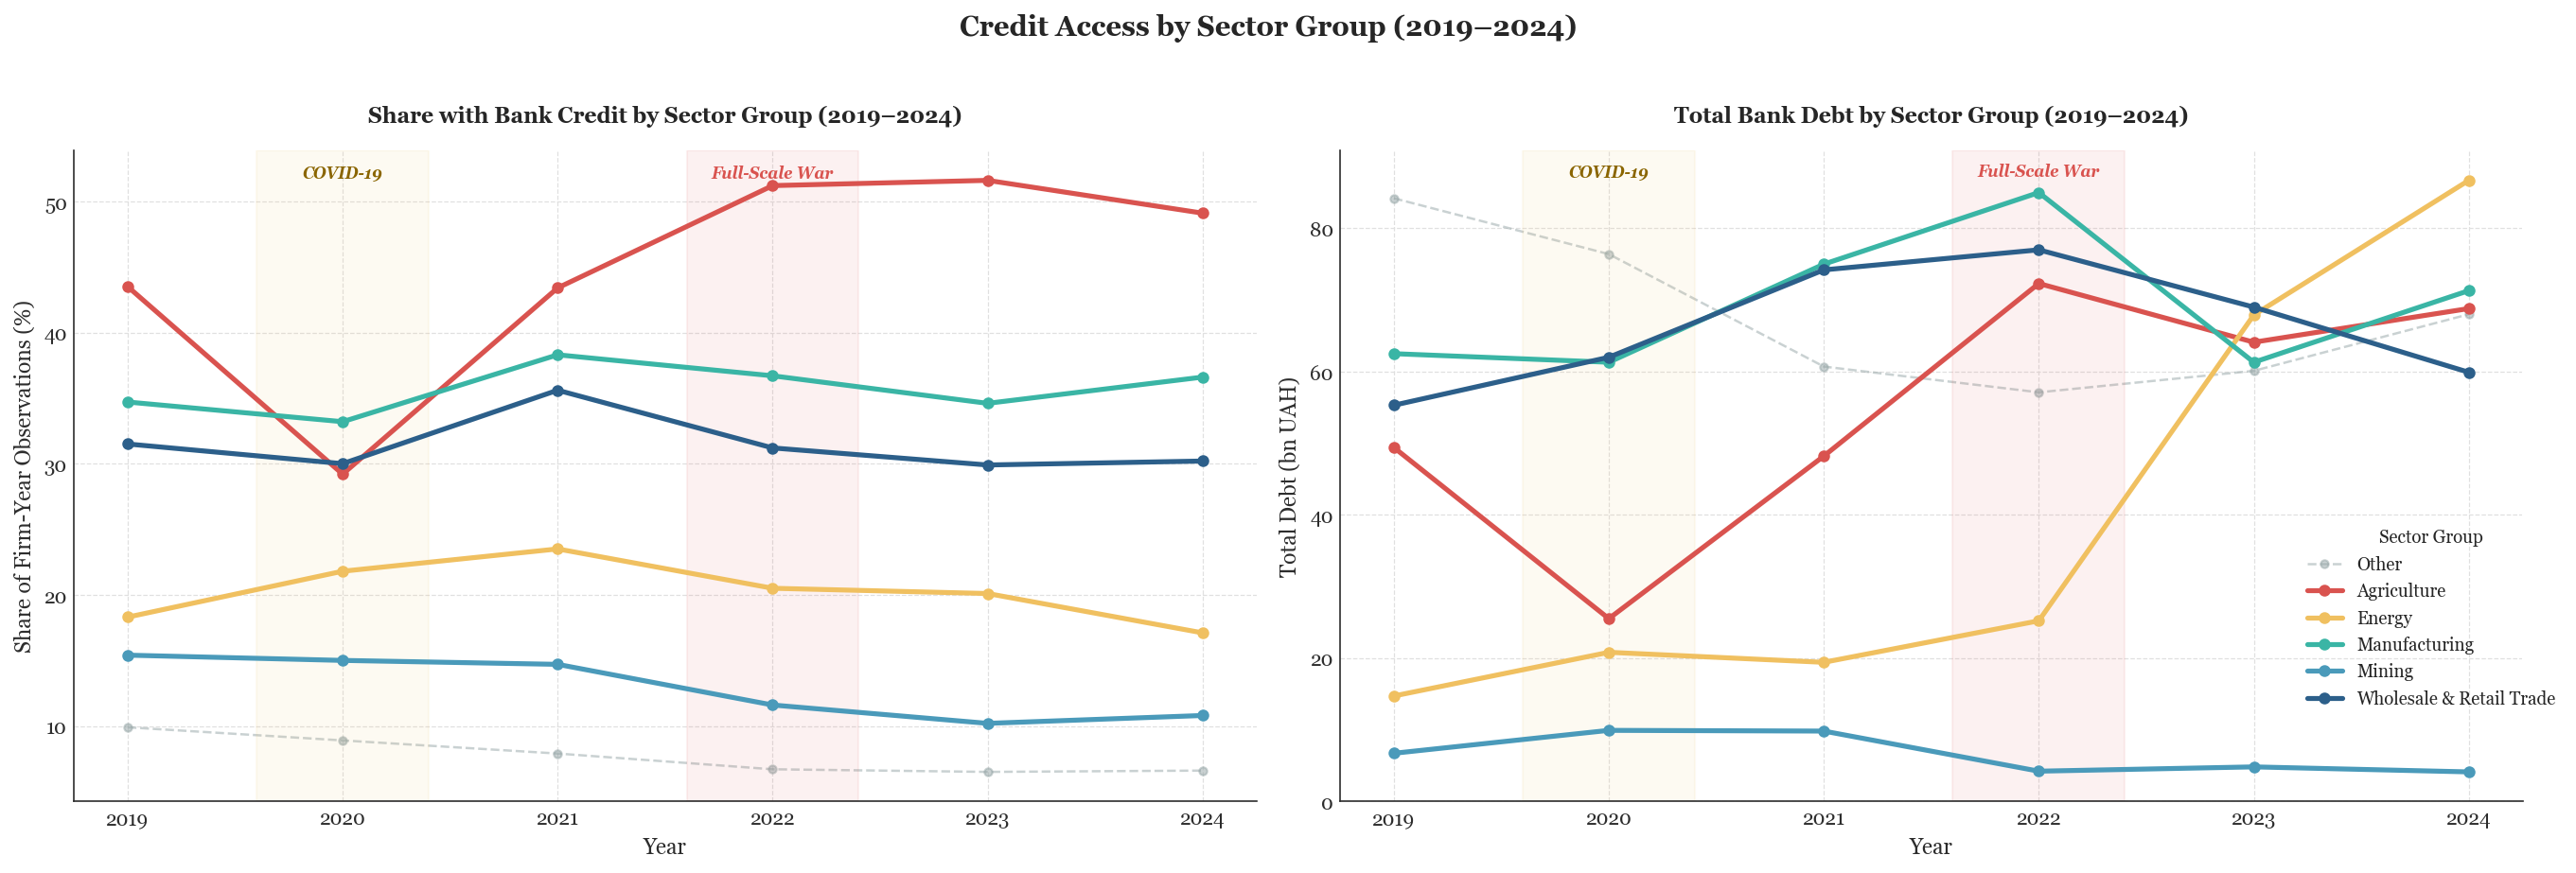

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, data, col, ylabel, title in [
    (axes[0], sector_credit_year, 'Has Credit (%)',
     'Share of Firm-Year Observations (%)',
     'Share with Bank Credit by Sector Group (2019–2024)'),
    (axes[1], sector_debt_year, 'Total Debt (bn UAH)',
     'Total Debt (bn UAH)',
     'Total Bank Debt by Sector Group (2019–2024)'),
]:
    other = data[data['Sector Group'] == 'Other']
    ax.plot(other['Year'], other[col], marker='o', markersize=4,
            color=COLORS['neutral'], linewidth=1.2,
            alpha=0.5, zorder=2, label='Other', linestyle='--')

    for sector, group in data[data['Sector Group'] != 'Other'].groupby('Sector Group'):
        ax.plot(group['Year'], group[col], marker='o', markersize=5,
                color=SECTOR_GROUP_COLORS[sector], linewidth=2.5,
                alpha=1.0, zorder=5, label=sector)

    ax.axvspan(2019.6, 2020.4, alpha=0.08, color=COLORS['accent'],   zorder=2)
    ax.axvspan(2021.6, 2022.4, alpha=0.08, color=COLORS['negative'], zorder=2)
    ax.text(2020, ax.get_ylim()[1] * 0.98, 'COVID-19',
            ha='center', fontsize=8, color='#8a6500',
            fontweight='bold', style='italic', va='top')
    ax.text(2022, ax.get_ylim()[1] * 0.98, 'Full-Scale War',
            ha='center', fontsize=8, color=COLORS['negative'],
            fontweight='bold', style='italic', va='top')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_xticks(YEARS_LAGGED)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.01, 0.31),
           fontsize=9, title='Sector Group', title_fontsize=9)
plt.suptitle('Credit Access by Sector Group (2019–2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('credit_access_debt_sector_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Summary table: all three dependent variables by sector (2019–2024)

Reporting Y1, Y2, and Y3 rates per sector group alongside firm counts and median debt.

In [23]:
sectors_order = TOP_SECTORS + ['Other']

rows = []
for sector in sectors_order:
    df_s = df_19[df_19['Sector Group'] == sector]
    median_d = df_s[df_s['Y1_Has_Credit'] == 1]['Total Debt'].median() / 1_000
    rows.append({
        'Sector'           : sector,
        'N firms'          : df_s['Firm ID'].nunique(),
        'N obs'            : len(df_s),
        'Y1 (%)'           : round(df_s['Y1_Has_Credit'].mean() * 100, 1),
        'Y2 (%)'           : round(df_s['Y2_Active_Credit_User'].mean() * 100, 1),
        'Y3 (%)'           : round(df_s['Y3_Increasing_Credit'].mean() * 100, 1),
        'Median debt (mn)' : round(median_d, 1),
    })

# Total row
median_total = df_19[df_19['Y1_Has_Credit'] == 1]['Total Debt'].median() / 1_000
rows.append({
    'Sector': 'Total',
    'N firms': df_19['Firm ID'].nunique(),
    'N obs':   len(df_19),
    'Y1 (%)':  round(df_19['Y1_Has_Credit'].mean() * 100, 1),
    'Y2 (%)':  round(df_19['Y2_Active_Credit_User'].mean() * 100, 1),
    'Y3 (%)':  round(df_19['Y3_Increasing_Credit'].mean() * 100, 1),
    'Median debt (mn)': round(median_total, 1),
})

table1 = pd.DataFrame(rows)
print('TABLE 1: DEPENDENT VARIABLES BY SECTOR (2019–2024)')
print(table1.to_string(index=False))
print('\nNote: Y1 = Has Credit; Y2 = Active Credit User; Y3 = Increasing Credit.')
print('      Median debt computed for Y1=1 observations only (mn UAH).')

TABLE 1: DEPENDENT VARIABLES BY SECTOR (2019–2024)
                  Sector  N firms  N obs  Y1 (%)  Y2 (%)  Y3 (%)  Median debt (mn)
Wholesale & Retail Trade     2901  10675    31.5    24.4    18.5              23.4
           Manufacturing     2957  11652    35.6    27.5    19.8              17.7
             Agriculture     2854  10687    46.5    35.5    26.4              17.7
                  Energy      442   1561    20.3    15.5    11.5              92.5
                  Mining      476   2053    12.9    10.6     6.7              10.0
                   Other     8489  33546     7.7     6.0     4.1              11.8
                   Total    18119  70174    22.3    17.1    12.5              18.5

Note: Y1 = Has Credit; Y2 = Active Credit User; Y3 = Increasing Credit.
      Median debt computed for Y1=1 observations only (mn UAH).


In [24]:
# TABLE 2: Y3 by sector group and year
rows2 = []
for sector in sectors_order:
    df_s = df_19[df_19['Sector Group'] == sector]
    row  = {'Sector': sector}
    for yr in YEARS_LAGGED:
        df_sy = df_s[df_s['Year'] == yr]
        row[str(yr)] = round(df_sy['Y3_Increasing_Credit'].mean() * 100, 1) if len(df_sy) > 0 else None
    row['Average'] = round(df_s['Y3_Increasing_Credit'].mean() * 100, 1)
    rows2.append(row)

row_total = {'Sector': 'Total'}
for yr in YEARS_LAGGED:
    df_y = df_19[df_19['Year'] == yr]
    row_total[str(yr)] = round(df_y['Y3_Increasing_Credit'].mean() * 100, 1)
row_total['Average'] = round(df_19['Y3_Increasing_Credit'].mean() * 100, 1)
rows2.append(row_total)

table2 = pd.DataFrame(rows2)
print('TABLE 2: Y3 (INCREASING CREDIT) BY SECTOR AND YEAR (%)')
print(table2.to_string(index=False))
print('\nNote: Share of firm-year observations with Y3=1 per sector-year cell.')

TABLE 2: Y3 (INCREASING CREDIT) BY SECTOR AND YEAR (%)
                  Sector  2019  2020  2021  2022  2023  2024  Average
Wholesale & Retail Trade  17.4  17.3  25.9  15.0  17.3  18.4     18.5
           Manufacturing  16.7  18.9  26.7  17.2  16.7  23.3     19.8
             Agriculture  25.3  14.9  13.6  37.1  25.3  23.2     26.4
                  Energy   7.7  19.3   8.8  13.6  13.4   6.3     11.5
                  Mining   9.7   9.2   8.7   4.4   5.0   4.9      6.7
                   Other   5.2   5.8   4.9   2.9   2.9   3.4      4.1
                   Total  13.7  11.5  13.2  13.0  11.1  12.1     12.5

Note: Share of firm-year observations with Y3=1 per sector-year cell.


## 17. Credit access by region

Computing Y1, Y2, and Y3 rates per region and identifying the top sector and top KVED by credit access rate.

In [25]:
region_p1 = (df.groupby('Region')['Y1_Has_Credit'].mean()
               .reset_index().rename(columns={'Y1_Has_Credit': 'Y1 (%)'}))
region_p2 = (df[df['Y2_Active_Credit_User'].notna()]
               .groupby('Region')['Y2_Active_Credit_User'].mean()
               .reset_index().rename(columns={'Y2_Active_Credit_User': 'Y2 (%)'}))
region_p3 = (df[df['Y3_Increasing_Credit'].notna()]
               .groupby('Region')['Y3_Increasing_Credit'].mean()
               .reset_index().rename(columns={'Y3_Increasing_Credit': 'Y3 (%)'}))

region_all = (region_p1
              .merge(region_p2, on='Region', how='left')
              .merge(region_p3, on='Region', how='left'))
region_all[['Y1 (%)','Y2 (%)','Y3 (%)']] = (region_all[['Y1 (%)','Y2 (%)','Y3 (%)']] * 100).round(1)

# Total debt per region
region_debt = (df.groupby('Region')['Total Debt'].sum()
                 .reset_index().rename(columns={'Total Debt': 'Total Debt (bn UAH)'}))
region_debt['Total Debt (bn UAH)'] = (region_debt['Total Debt (bn UAH)'] / 1_000_000).round(1)
region_debt['Debt Share (%)']      = (region_debt['Total Debt (bn UAH)'] /
                                      region_debt['Total Debt (bn UAH)'].sum() * 100).round(1)

# Top sector per region by credit access rate
def top_by_credit(group_col, value_col):
    return (
        df.groupby(['Region', group_col])[value_col].mean()
        .reset_index()
        .sort_values(value_col, ascending=False)
        .groupby('Region').first()
        .reset_index()
    )

top_sector = top_by_credit('Sector', 'Y1_Has_Credit')
top_sector['Sector Label'] = top_sector['Sector'].map(SECTOR_MAP)
top_sector['Top Sector (%)'] = (top_sector['Y1_Has_Credit'] * 100).round(1)

top_kved = top_by_credit('KVED', 'Y1_Has_Credit')
top_kved['Top KVED (%)'] = (top_kved['Y1_Has_Credit'] * 100).round(1)

region_full = (
    region_all
    .merge(region_debt, on='Region')
    .merge(top_sector[['Region','Sector Label','Top Sector (%)']], on='Region')
    .merge(top_kved[['Region','KVED','Top KVED (%)']], on='Region')
    .sort_values('Y1 (%)', ascending=False)
)

print('Credit Access by Region — All Three Dependent Variables:')
print(region_full[['Region','Y1 (%)','Y2 (%)','Y3 (%)','Total Debt (bn UAH)',
                   'Debt Share (%)','Sector Label','Top Sector (%)','KVED','Top KVED (%)']]
      .to_string(index=False))

Credit Access by Region — All Three Dependent Variables:
                   Region  Y1 (%)  Y2 (%)  Y3 (%)  Total Debt (bn UAH)  Debt Share (%)             Sector Label  Top Sector (%)  KVED  Top KVED (%)
        Волинська область    38.5    27.8    22.9                 60.9             2.9              Real Estate            60.0 17.12         100.0
        Черкаська область    35.5    26.2    18.7                 81.3             3.9 Wholesale & Retail Trade            51.9  1.13         100.0
        Вінницька область    33.9    26.2    20.3                 80.7             3.8              Agriculture            50.9 52.29         100.0
   Кіровоградська область    33.7    25.3    18.7                 31.6             1.5              Agriculture            48.3  1.41         100.0
          Сумська область    32.7    21.9    15.6                 64.2             3.1              Agriculture            43.1 20.59         100.0
    Тернопільська область    32.5    24.4    19.0      

## 18. Credit access by region — bar and time series charts

Visualising Y1 and total debt by region as horizontal bars, grouped by conflict exposure. Then showing Y1 and total debt dynamics by region group over 2019–2024.

/var/folders/02/hb5ht0zx44137l9lqlhhqg380000gn/T/ipykernel_56169/2727229116.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(data['Region EN'].tolist(), fontsize=8.5)


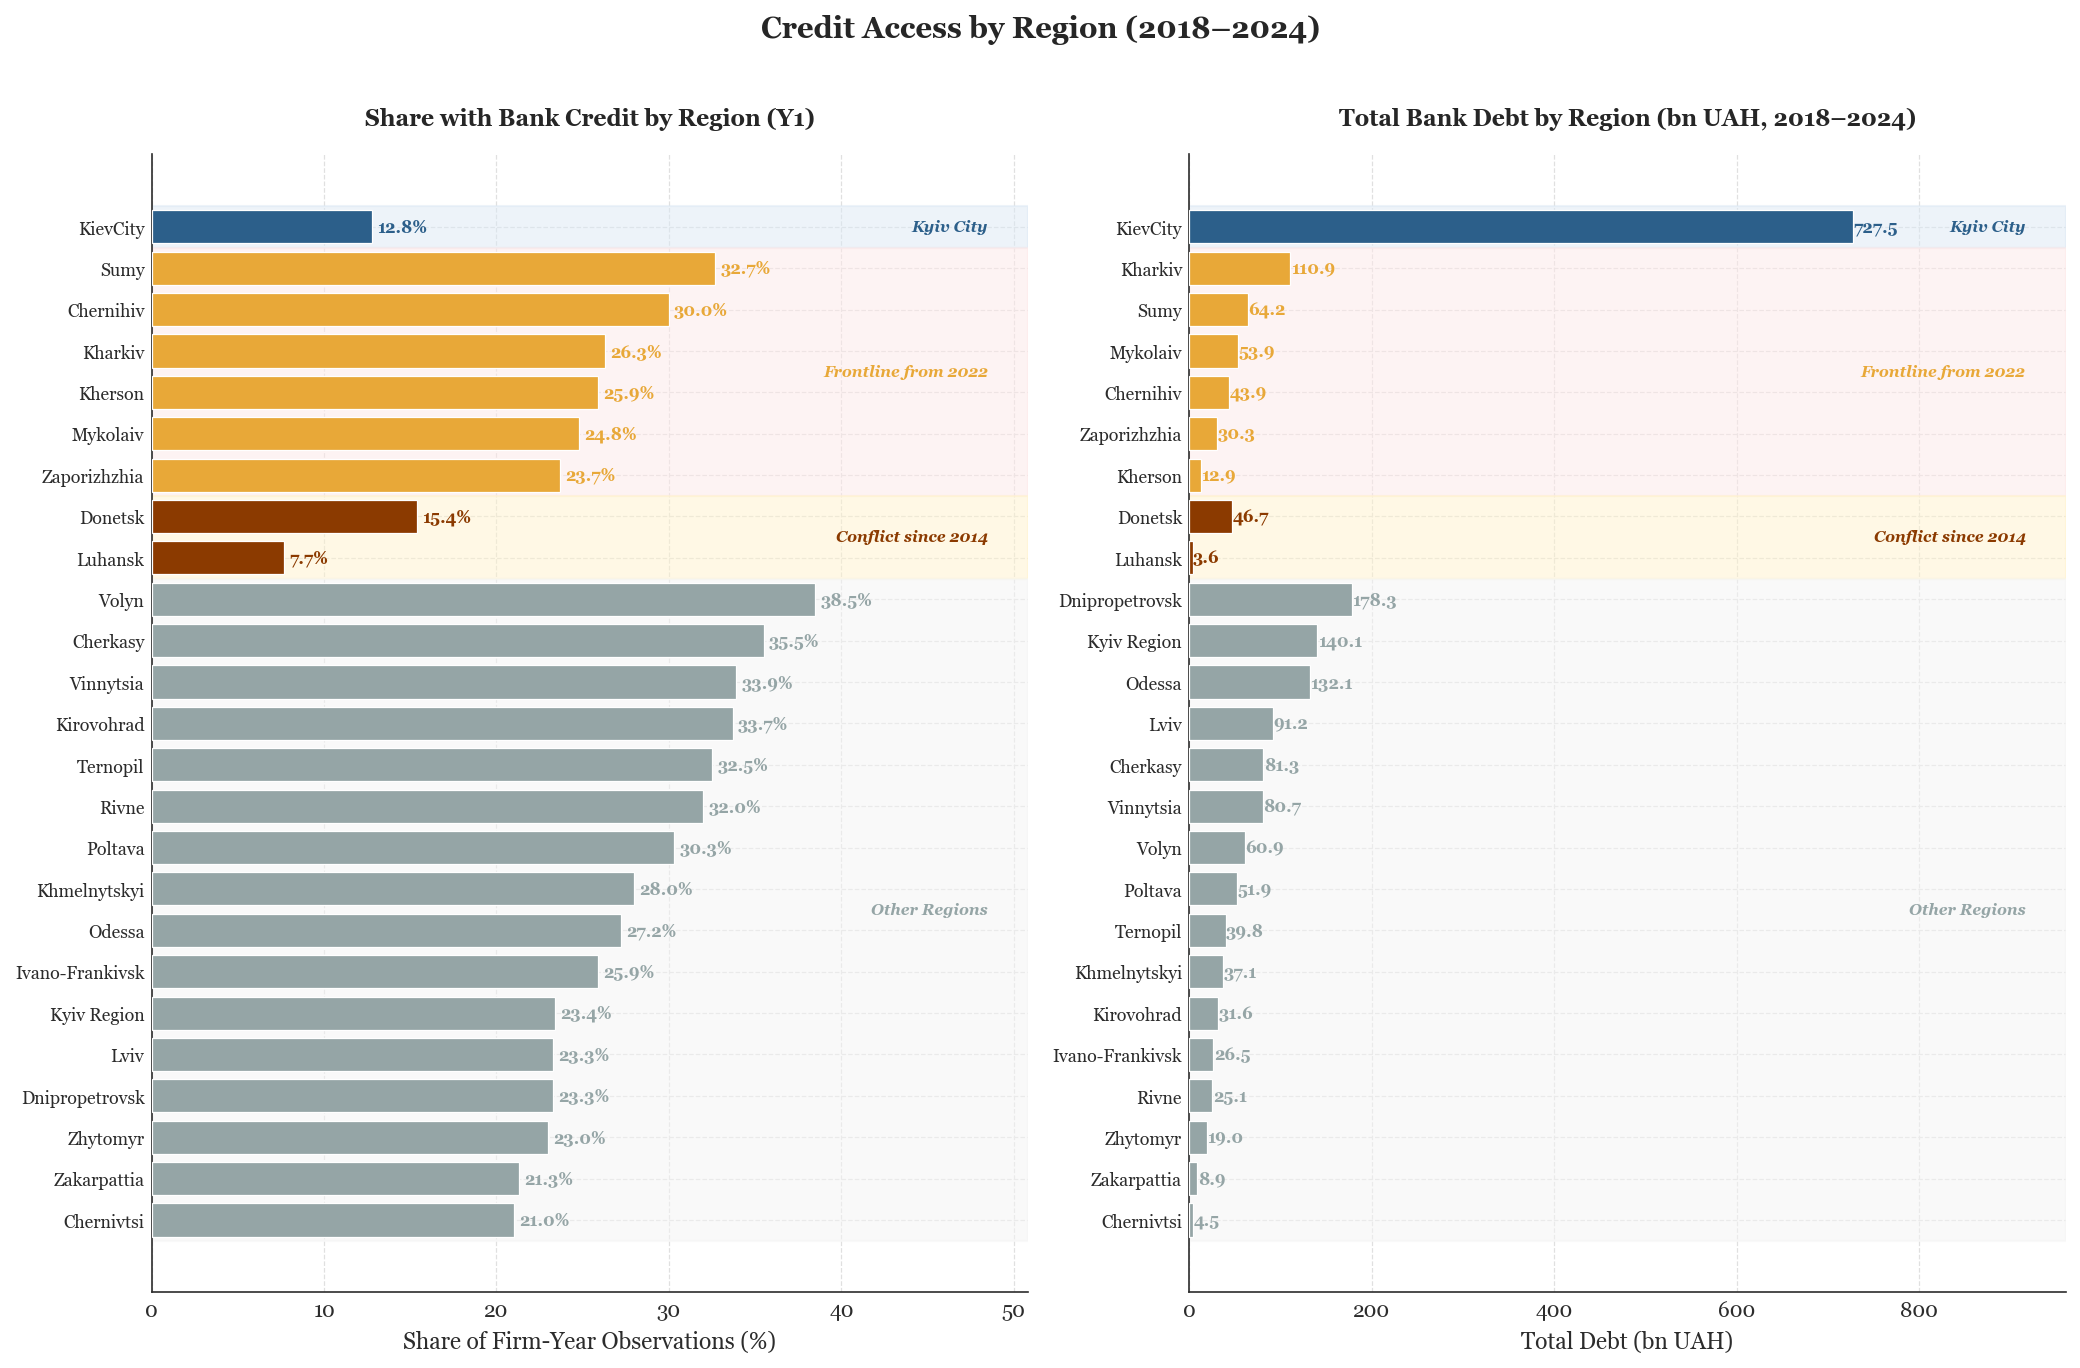

In [27]:
REGION_GROUP_COLORS = {
    'Kyiv City':           COLORS['primary'],
    'Other Regions':       COLORS['neutral'],
    'Conflict since 2014': '#8B3A00',
    'Frontline from 2022': '#E8A838',
}
GROUP_BG_COLORS = {
    'Kyiv City':           '#dce9f5',
    'Frontline from 2022': '#fde8e8',
    'Conflict since 2014': '#fff3cd',
    'Other Regions':       '#f5f5f5',
}
GROUP_ORDER = ['Kyiv City', 'Frontline from 2022', 'Conflict since 2014', 'Other Regions']

region_bar = (
    region_full[['Region','Y1 (%)','Total Debt (bn UAH)']]
    .merge(df[['Region','Region Group','Region EN']].drop_duplicates(), on='Region')
)
region_bar['Group Order'] = region_bar['Region Group'].map(
    {g: i for i, g in enumerate(GROUP_ORDER)}
)
region_bar = region_bar.sort_values(['Group Order','Y1 (%)'],
                                    ascending=[True, False]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 9))

for ax, data_col, xlabel, title in [
    (axes[0], 'Y1 (%)', 'Share of Firm-Year Observations (%)',
     'Share with Bank Credit by Region (Y1)'),
    (axes[1], 'Total Debt (bn UAH)', 'Total Debt (bn UAH)',
     'Total Bank Debt by Region (bn UAH, 2018–2024)'),
]:
    data = (region_bar.sort_values(['Group Order', data_col],
                                   ascending=[True, False])
                      .reset_index(drop=True))
    n = len(data)

    current_group, group_start = None, 0
    for i, (_, row) in enumerate(data.iterrows()):
        if row['Region Group'] != current_group:
            if current_group is not None:
                ax.axhspan(group_start - 0.5, i - 0.5,
                           color=GROUP_BG_COLORS[current_group], alpha=0.5, zorder=1)
                ax.text(data[data_col].max() * 1.26, (group_start + i - 1) / 2,
                        current_group, va='center', ha='right', fontsize=7.5,
                        color=REGION_GROUP_COLORS[current_group],
                        fontweight='bold', style='italic')
            current_group, group_start = row['Region Group'], i
    ax.axhspan(group_start - 0.5, n - 0.5,
               color=GROUP_BG_COLORS[current_group], alpha=0.5, zorder=1)
    ax.text(data[data_col].max() * 1.26, (group_start + n - 1) / 2,
            current_group, va='center', ha='right', fontsize=7.5,
            color=REGION_GROUP_COLORS[current_group],
            fontweight='bold', style='italic')

    bars = ax.barh(data['Region EN'].tolist(), data[data_col],
                   color=[REGION_GROUP_COLORS[g] for g in data['Region Group']],
                   edgecolor='white', linewidth=0.6, zorder=3)

    suffix = '%' if data_col == 'Y1 (%)' else ''
    for bar, val, grp in zip(bars, data[data_col], data['Region Group']):
        ax.text(bar.get_width() + (0.3 if suffix else 0.5),
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}{suffix}', va='center', fontsize=8,
                color=REGION_GROUP_COLORS[grp], fontweight='bold')

    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, data[data_col].max() * 1.32)
    ax.set_yticklabels(data['Region EN'].tolist(), fontsize=8.5)

plt.suptitle('Credit Access by Region (2018–2024)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('credit_access_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

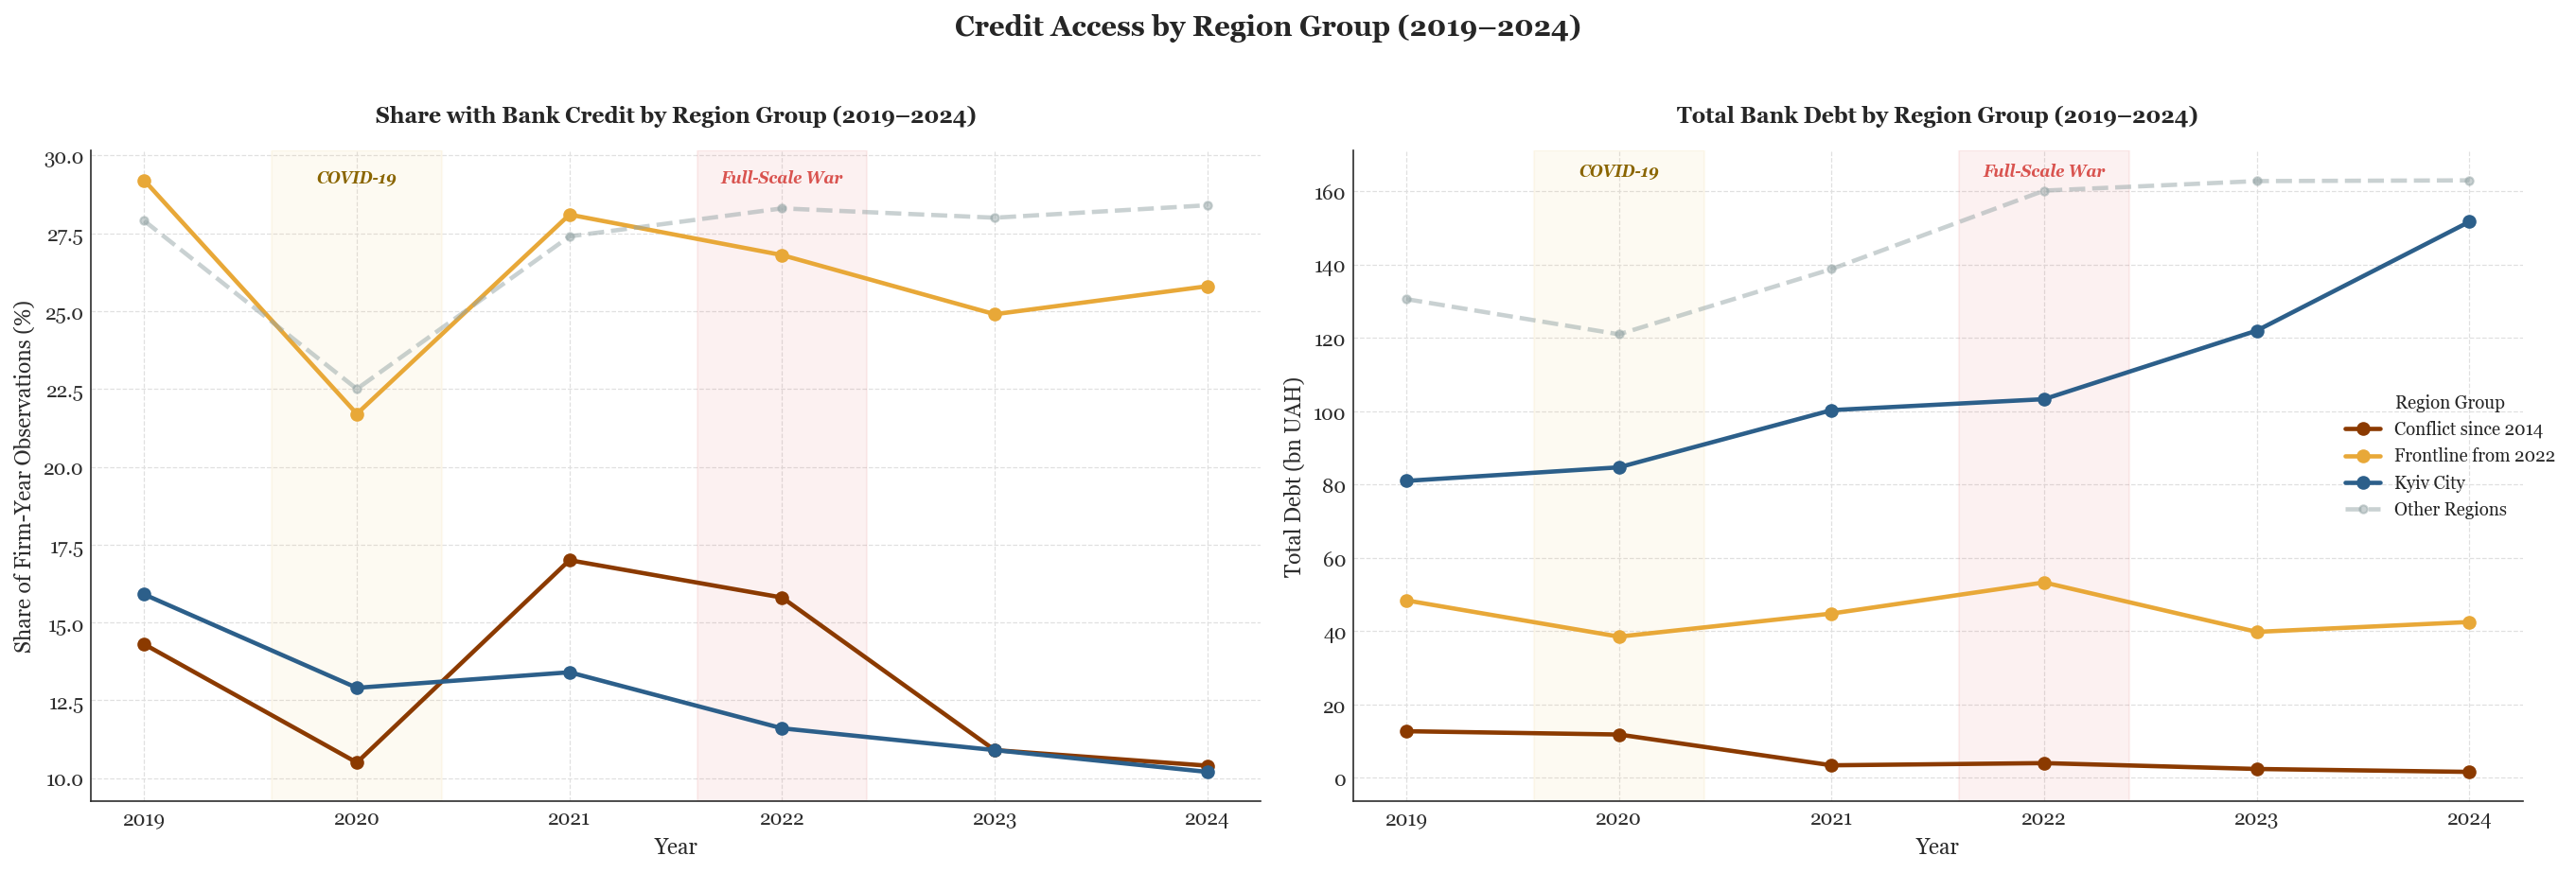

In [28]:
# Credit access and total debt by region group over time
region_credit_year = (
    df_19.groupby(['Year', 'Region Group'])['Y1_Has_Credit'].mean()
    .reset_index().rename(columns={'Y1_Has_Credit': 'Has Credit (%)'})
)
region_credit_year['Year']           = region_credit_year['Year'].astype(int)
region_credit_year['Has Credit (%)'] = (region_credit_year['Has Credit (%)'] * 100).round(1)

region_debt_year = (
    df_19.groupby(['Year', 'Region Group'])['Total Debt'].sum()
    .reset_index()
)
region_debt_year['Year']                = region_debt_year['Year'].astype(int)
region_debt_year['Total Debt (bn UAH)'] = (region_debt_year['Total Debt'] / 1_000_000).round(1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, data, col, ylabel, title in [
    (axes[0], region_credit_year, 'Has Credit (%)',
     'Share of Firm-Year Observations (%)',
     'Share with Bank Credit by Region Group (2019–2024)'),
    (axes[1], region_debt_year, 'Total Debt (bn UAH)',
     'Total Debt (bn UAH)',
     'Total Bank Debt by Region Group (2019–2024)'),
]:
    for group, group_data in data.groupby('Region Group'):
        group_data = group_data.sort_values('Year')
        ls = '--' if group == 'Other Regions' else '-'
        a  = 0.5  if group == 'Other Regions' else 1.0
        ms = 4    if group == 'Other Regions' else 6
        ax.plot(group_data['Year'], group_data[col],
                marker='o', markersize=ms,
                color=REGION_GROUP_COLORS[group], linewidth=2.2,
                linestyle=ls, alpha=a, zorder=5, label=group)

    ax.axvspan(2019.6, 2020.4, alpha=0.08, color=COLORS['accent'],   zorder=2)
    ax.axvspan(2021.6, 2022.4, alpha=0.08, color=COLORS['negative'], zorder=2)
    ax.text(2020, ax.get_ylim()[1] * 0.98, 'COVID-19',
            ha='center', fontsize=8, color='#8a6500',
            fontweight='bold', style='italic', va='top')
    ax.text(2022, ax.get_ylim()[1] * 0.98, 'Full-Scale War',
            ha='center', fontsize=8, color=COLORS['negative'],
            fontweight='bold', style='italic', va='top')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_xticks(YEARS_LAGGED)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.01, 0.5),
           fontsize=9, title='Region Group', title_fontsize=9)
plt.suptitle('Credit Access by Region Group (2019–2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('credit_access_debt_region_combined.png', dpi=150, bbox_inches='tight')
plt.show()